# Boltzmann to Maxwell Ratio

This notebook computes Argon EEDFs with BOLOS, builds a Maxwellian with the same mean electron energy for each case, and plots `f_Boltzmann / f_Maxwell`.

Use the dropdown widget to switch the displayed `E/N` interactively.

In [1]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from argon_eedf_bolos import compute_eedf

In [2]:
cross_section_path = Path("argon cross section.txt")

en_td_values = [5.0, 10.0, 20.0, 40.0, 80.0, 120.0, 200.0, 300.0]

base_params = {
    "species": "Ar",
    "gas_temperature_k": 300.0,
    "cells": 300,
    "max_energy_ev": 60.0,
    "initial_te_ev": 2.0,
    "max_iterations": 200,
    "rtol": 1e-5,
}

results = []
for en_td in en_td_values:
    result = compute_eedf(cross_section_path, en_td=en_td, **base_params)
    solver = result["solver"]
    f_boltzmann = np.asarray(result["eedf"])
    f_maxwell = np.asarray(solver.maxwell(result["mean_energy_eV"]))
    ratio = np.divide(
        f_boltzmann,
        f_maxwell,
        out=np.full_like(f_boltzmann, np.nan),
        where=f_maxwell > 0,
    )

    results.append(
        {
            **result,
            "f_maxwell": f_maxwell,
            "ratio": ratio,
        }
    )

results_by_en_td = {result["en_td"]: result for result in results}
len(results)

c:\Users\kobun\anaconda3\Lib\site-packages\bolos\solver.py:587: RuntimeWarning: divide by zero encountered in divide
  sigma_tilde = self.sigma_m + nu / np.sqrt(self.benergy) / GAMMA
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\solver.py:653: RuntimeWarning: invalid value encountered in log
  g = np.log(Fp[2:] / Fp[:-2]) / (cenergyp[2:] - cenergyp[:-2])
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\solver.py:653: RuntimeWarning: divide by zero encountered in divide
  g = np.log(Fp[2:] / Fp[:-2]) / (cenergyp[2:] - cenergyp[:-2])
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\solver.py:653: RuntimeWarning: divide by zero encountered in log
  g = np.log(Fp[2:] / Fp[:-2]) / (cenergyp[2:] - cenergyp[:-2])
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\process.py:190: RuntimeWarning: invalid value encountered in add
  A1 = (  expm1a * ag1 + ag
c:\Users\kobun\anaconda3\Lib\site-packages\bolos\process.py:190: RuntimeWarning: invalid value encountered in subtract
  A1 = (  expm1a * a

8

In [3]:
summary_df = pd.DataFrame(
    {
        "en_td": [result["en_td"] for result in results],
        "mean_energy_eV": [result["mean_energy_eV"] for result in results],
        "mobility_n_SI": [result["mobility_n_SI"] for result in results],
        "diffusion_n_SI": [result["diffusion_n_SI"] for result in results],
    }
)
summary_df

,en_td,mean_energy_eV,mobility_n_SI,diffusion_n_SI
0,5.0,4.884021,9.611972e+23,7.766574e+24
1,10.0,5.353187,9.683551e+23,7.515474e+24
2,20.0,5.628280,9.403454e+23,7.366453e+24
3,40.0,6.005803,8.699234e+23,7.130228e+24
4,80.0,6.542451,7.992233e+23,6.826165e+24
5,120.0,6.964933,7.613727e+23,6.587331e+24
6,200.0,7.689803,7.138597e+23,6.239862e+24
7,300.0,8.525718,6.751865e+23,5.996391e+24


In [4]:
ratio_df = pd.concat(
    [
        pd.DataFrame(
            {
                "en_td": result["en_td"],
                "energy_eV": result["energy_eV"],
                "f_boltzmann": result["eedf"],
                "f_maxwell": result["f_maxwell"],
                "ratio_boltzmann_to_maxwell": result["ratio"],
            }
        )
        for result in results
    ],
    ignore_index=True,
)
ratio_df.head()

,en_td,energy_eV,f_boltzmann,f_maxwell,ratio_boltzmann_to_maxwell
0,5.0,0.000408,0.075068,0.104533,0.718125
1,5.0,0.002038,0.075068,0.104498,0.718365
2,5.0,0.005300,0.075068,0.104428,0.718845
3,5.0,0.010191,0.075068,0.104324,0.719565
4,5.0,0.016714,0.075068,0.104184,0.720527


In [5]:
def plot_selected_en_td(en_td):
    result = results_by_en_td[en_td]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].semilogy(result["energy_eV"], result["eedf"], lw=2, label="Boltzmann")
    axes[0].semilogy(
        result["energy_eV"],
        result["f_maxwell"],
        lw=2,
        ls="--",
        label="Maxwell (same mean energy)",
    )
    axes[0].set_title(f"EEDF comparison at {en_td:.0f} Td")
    axes[0].set_xlabel("Energy [eV]")
    axes[0].set_ylabel("f(E)")
    axes[0].set_ylim(bottom=1e-15)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(result["energy_eV"], result["ratio"], lw=2, color="tab:green")
    axes[1].axhline(1.0, color="black", ls="--", lw=1)
    axes[1].set_title(f"f_Boltzmann / f_Maxwell at {en_td:.0f} Td")
    axes[1].set_xlabel("Energy [eV]")
    axes[1].set_ylabel("Ratio")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


en_td_dropdown = widgets.Dropdown(
    options=en_td_values,
    value=120.0,
    description="E/N [Td]",
)

interactive_plot = widgets.interactive_output(
    plot_selected_en_td,
    {"en_td": en_td_dropdown},
)

display(en_td_dropdown, interactive_plot)

Dropdown(description='E/N [Td]', index=5, options=(5.0, 10.0, 20.0, 40.0, 80.0, 120.0, 200.0, 300.0), value=12…

Output()

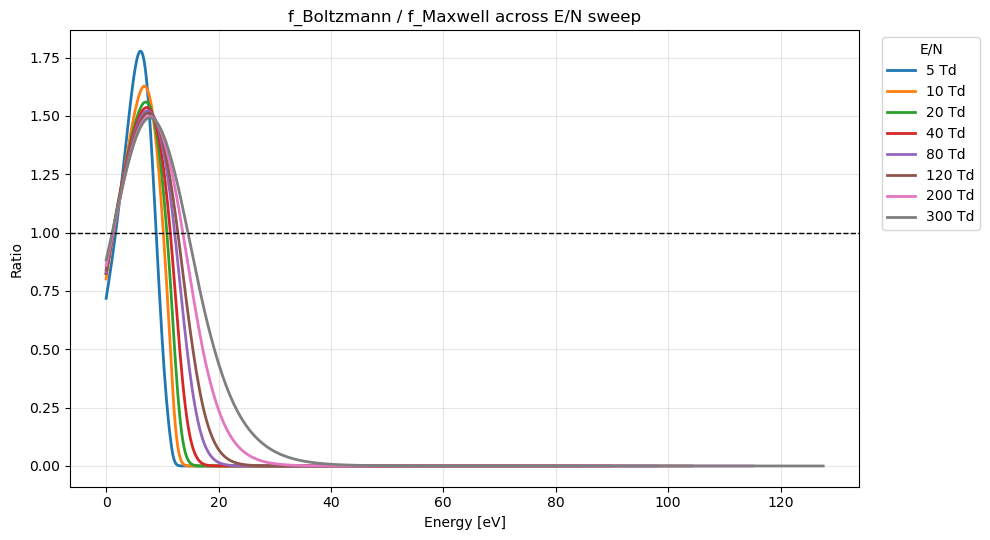

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for result in results:
    ax.plot(result["energy_eV"], result["ratio"], lw=2, label=f"{result['en_td']:.0f} Td")

ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_title("f_Boltzmann / f_Maxwell across E/N sweep")
ax.set_xlabel("Energy [eV]")
ax.set_ylabel("Ratio")
ax.grid(True, alpha=0.3)
ax.legend(title="E/N", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

In [7]:
ratio_summary_df = pd.DataFrame(
    {
        "en_td": [result["en_td"] for result in results],
        "max_ratio": [np.nanmax(result["ratio"]) for result in results],
        "min_ratio": [np.nanmin(result["ratio"]) for result in results],
    }
)
ratio_summary_df

,en_td,max_ratio,min_ratio
0,5.0,1.777609,-1.241875e-11
1,10.0,1.627428,-3.947330e-14
2,20.0,1.559468,-1.266745e-14
3,40.0,1.535736,-3.199870e-13
4,80.0,1.521712,5.736026e-28
5,120.0,1.512264,7.767761e-17
6,200.0,1.498525,1.546933e-09
7,300.0,1.491613,1.256074e-06


In [8]:
ratio_output_csv = Path("argon_boltzmann_to_maxwell_ratio.csv")
summary_output_csv = Path("argon_boltzmann_to_maxwell_ratio_summary.csv")

ratio_df.to_csv(ratio_output_csv, index=False)
ratio_summary_df.to_csv(summary_output_csv, index=False)

ratio_output_csv.resolve(), summary_output_csv.resolve()

(WindowsPath('C:/workspace/argon_boltzmann_to_maxwell_ratio.csv'),
 WindowsPath('C:/workspace/argon_boltzmann_to_maxwell_ratio_summary.csv'))